<a href="https://colab.research.google.com/github/festusoladayoonline-debug/Beyond-Potency-NorA/blob/main/amr_ecoli_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting antimicrobial resistance (AMR) in *E. coli*: replicate, critique, improve

**Reference paper:** Adeyemi & Paudel (2026), *Integrating Phenotypic and Genomic Data with Machine Learning to Predict Antimicrobial Resistance and Identify Genetic Biomarkers in E. coli*, Int. J. Environ. Res. Public Health 23, 561.

This notebook does three things, in this order:

| Part | What you do | Why |
|---|---|---|
| **1-2** | Retrieve BV-BRC AST data, clean it as the paper did | Reproduce the data foundation |
| **3** | Replicate the paper's 5-model benchmark, then expose its main weakness with baselines | Learn *why* the headline numbers are less impressive than they look |
| **4-6** | Annotate genomes, build a tree with a real clustering test, and train models on **genome-derived features** with lineage-aware validation, SHAP and statistics | The version of the study that actually predicts resistance from biology |
| **7-8** | Save outputs, reproducibility log, checklist of paper issues vs. fixes | Publishable hygiene |

**How to run it.** Colab is fine for Parts 1-3 (pure Python). Parts 4-6 call command-line tools (AMRFinderPlus, mashtree, MAFFT, FastTree, optionally RGI and ResFinder), so use either Colab with `condacolab` or a local conda environment (`environment.yml` is provided alongside this notebook). On Windows use WSL2.

**Honest caveat.** The BV-BRC API calls and tool commands in this notebook were written against current documentation, but I could not run them against the live services myself. Cells that talk to BV-BRC or external tools print what they receive so you can spot a changed field name or flag quickly. The analysis code (cleaning, models, baselines, tree statistics, SHAP) was tested end-to-end on synthetic data shaped like the BV-BRC output.

In [ ]:
!pip -q install condacolab
import condacolab; condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


In [ ]:
%%capture
# 1. Install primary tools and python dependencies into the base environment
!mamba install -y -c conda-forge -c bioconda mafft fasttree ncbi-amrfinderplus blast kma rgi resfinder
!amrfinder -u
!pip -q install xgboost shap biopython statsmodels tqdm seaborn

# 2. Create an isolated Python 3.10 environment for mashtree
!mamba create -y -n bio_legacy -c conda-forge -c bioconda python=3.10 mashtree

In [ ]:
# 3. Verification check for all tools
from pathlib import Path
import shutil
import importlib.util

print("=== Environment Verification ===")

# Check standard path binaries
base_tools = ["mafft", "fasttree", "amrfinder", "blastn", "kma", "rgi"]
for tool in base_tools:
    path = shutil.which(tool)
    status = f"Installed ({path})" if path else "MISSING"
    print(f"  {tool:<15} -> {status}")

# Check isolated mashtree binary
mashtree_path = Path("/usr/local/envs/bio_legacy/bin/mashtree")
mashtree_status = f"Installed ({mashtree_path})" if mashtree_path.exists() else "MISSING"
print(f"  {'mashtree':<15} -> {mashtree_status}")

# Check ResFinder Python module
resfinder_spec = importlib.util.find_spec("resfinder")
resfinder_status = "Installed (Python Module)" if resfinder_spec is not None else "MISSING"
print(f"  {'resfinder':<15} -> {resfinder_status}")

=== Environment Verification ===
  mafft           -> Installed (/usr/local/bin/mafft)
  fasttree        -> Installed (/usr/local/bin/fasttree)
  amrfinder       -> Installed (/usr/local/bin/amrfinder)
  blastn          -> Installed (/usr/local/bin/blastn)
  kma             -> Installed (/usr/local/bin/kma)
  rgi             -> Installed (/usr/local/bin/rgi)
  mashtree        -> Installed (/usr/local/envs/bio_legacy/bin/mashtree)
  resfinder       -> Installed (Python Module)


## 0. Environment

**Option A, local Anaconda / Miniconda (recommended for the full pipeline):**
```bash
conda env create -f environment.yml
conda activate amr-ml
amrfinder -u          # download the AMRFinderPlus database once
jupyter lab
```

**Option B, Colab.** Run once, the runtime restarts after `condacolab.install()`:
```python
!pip -q install condacolab
import condacolab; condacolab.install()
```
then after the restart:
```python
!mamba install -y -c conda-forge -c bioconda mafft fasttree mashtree ncbi-amrfinderplus blast kma
!amrfinder -u
!pip -q install xgboost shap biopython statsmodels tqdm seaborn
# optional, only for the paper-tool cross-check in Part 4.3:
!mamba install -y -c bioconda rgi
!pip -q install resfinder
```
To keep data across Colab sessions, mount Drive and set `ROOT = Path("/content/drive/MyDrive/amr_project")` in the config cell.

In [ ]:
import os
os.environ["PATH"] += os.pathsep + "/usr/local/envs/bio_legacy/bin"
import sys, shutil, subprocess, platform
from pathlib import Path
import urllib.request
import urllib.parse

IN_COLAB = "google.colab" in sys.modules
print("Python", platform.python_version(), "| Colab:", IN_COLAB)

TOOLS = {
    "amrfinder (AMRFinderPlus)": ["amrfinder"],
    "mashtree": ["mashtree"],
    "mafft": ["mafft"],
    "FastTree": ["FastTree", "fasttree"],
    "rgi (CARD, optional)": ["rgi"],
    "resfinder (optional)": ["run_resfinder.py", "resfinder"],
}
for label, names in TOOLS.items():
    found = next((shutil.which(n) for n in names if shutil.which(n)), None)
    print(f"{label:28s}", "OK  " + found if found else "not found")

Python 3.13.15 | Colab: True
amrfinder (AMRFinderPlus)    OK  /usr/local/bin/amrfinder
mashtree                     OK  /usr/local/envs/bio_legacy/bin/mashtree
mafft                        OK  /usr/local/bin/mafft
FastTree                     OK  /usr/local/bin/FastTree
rgi (CARD, optional)         OK  /usr/local/bin/rgi
resfinder (optional)         OK  /usr/local/bin/run_resfinder.py


In [ ]:
import os, re, json, time, warnings, random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

# ---------------- configuration ----------------
SEED = 42
rng = np.random.default_rng(SEED); random.seed(SEED); np.random.seed(SEED)

TAXON_ID = 562                # Escherichia coli in the NCBI taxonomy
LAB_EVIDENCE_ONLY = True      # keep laboratory AST only, drop computationally predicted phenotypes
N_GENOMES = 300               # genomes to download/annotate for Parts 4-6 (raise once the pipeline works)
N_THREADS = 4
ENTREZ_EMAIL = "festusoladayoonline@gmail.com"   # NCBI asks for a real address

RUN_PAPER_TOOLS = False       # Part 4.3: also run CARD RGI + ResFinder on a few genomes
N_CROSSCHECK = 10
RUN_PAPER_STYLE_TREE = False  # Part 5.3: whole-genome MAFFT + FastTree as in the paper (small subset only)
N_TREE_WGA = 15
OUTGROUP_IDS = []             # optional BV-BRC genome_ids (e.g. Cronobacter) to root the paper-style tree
CLUSTERS_FOR_CV = 20          # lineage groups used for leakage-aware cross-validation

ROOT = Path("amr_project")
DATA, GENOMES, ANNOT, RES = ROOT/"data", ROOT/"data"/"genomes", ROOT/"data"/"annotations", ROOT/"results"
for p in (DATA, GENOMES, ANNOT, RES):
    p.mkdir(parents=True, exist_ok=True)
print("Project folder:", ROOT.resolve())

Project folder: /content/amr_project


## Part 1. Data retrieval (BV-BRC)

BV-BRC exposes every table through a REST API that speaks RQL (Resource Query Language). We need three things:
1. **AST phenotypes** (`genome_amr` collection): one row per genome-antibiotic test.
2. **Genome FASTA files** (`genome_sequence` collection) for the genomes we annotate.
3. **The K-12 MG1655 reference** (`U00096.3`) from NCBI via Biopython Entrez.

Note the unit of observation: **one row = one isolate-antibiotic test**, not one isolate. This matters for validation in Part 6.

If the API ever changes, the manual fallback is the BV-BRC website: *Genomes -> filter E. coli -> AMR Phenotypes tab -> Download CSV*, then load that file into `raw` below.

In [ ]:
import requests

API = "https://www.bv-brc.org/api"
AMR_FIELDS = ",".join([
    "genome_id", "genome_name", "taxon_id", "antibiotic", "resistant_phenotype",
    "measurement", "measurement_sign", "measurement_value", "measurement_unit",
    "laboratory_typing_method", "laboratory_typing_method_version", "laboratory_typing_platform",
    "vendor", "testing_standard", "testing_standard_year", "computational_method", "evidence",
])

def bvbrc_get(collection, rql, accept="application/json", retries=3, timeout=180):
    """GET with retry/backoff. `rql` is the raw query string, e.g. 'eq(taxon_id,562)&limit(10)'."""
    url = f"{API}/{collection}/?{rql}"
    last = None
    for k in range(retries):
        try:
            r = requests.get(url, headers={"Accept": accept}, timeout=timeout)
            if r.status_code == 200:
                return r
            last = RuntimeError(f"HTTP {r.status_code} for {url[:200]}")
        except requests.RequestException as e:
            last = e
        time.sleep(2 ** k)
    raise last

def fetch_amr(taxon_id, page=25000, max_pages=60):
    frames, start = [], 0
    for _ in range(max_pages):
        r = bvbrc_get("genome_amr", f"eq(taxon_id,{taxon_id})&select({AMR_FIELDS})&limit({page},{start})")
        chunk = pd.DataFrame(r.json())
        if chunk.empty:
            break
        frames.append(chunk)
        start += page
        if len(chunk) < page:
            break
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

In [ ]:
RAW = DATA / "raw_amr.csv"
if RAW.exists():
    raw = pd.read_csv(RAW, dtype=str)
    print("Loaded cached", RAW)
else:
    raw = fetch_amr(TAXON_ID)
    if raw.empty:
        raise RuntimeError("No rows returned. Check connectivity, or download the AMR table manually "
                           "from the BV-BRC website and load it into `raw`.")
    raw.to_csv(RAW, index=False)
print(raw.shape)
display(raw.head())
print("Columns:", list(raw.columns))

Loaded cached amr_project/data/raw_amr.csv
(1500000, 17)


,antibiotic,resistant_phenotype,evidence,genome_id,genome_name,taxon_id,measurement,measurement_value,laboratory_typing_method,vendor,testing_standard,measurement_sign,measurement_unit,testing_standard_year,laboratory_typing_platform,laboratory_typing_method_version,computational_method
0,ciprofloxacin,Resistant,Laboratory Method,562.56783,Escherichia coli strain 372-13,562,NaN,NaN,Disk diffusion,Oxoid,EUCAST,NaN,NaN,NaN,NaN,NaN,NaN
1,meropenem,Susceptible,Laboratory Method,562.99772,Escherichia coli ce527c70-7bb8-11e9-a8d3-68b59...,562,NaN,NaN,Disk diffusion,NaN,EUCAST,NaN,NaN,NaN,NaN,NaN,NaN
2,meropenem,Susceptible,Laboratory Method,562.99136,Escherichia coli aa1e9e8c-7bb9-11e9-a8d3-68b59...,562,NaN,NaN,Disk diffusion,NaN,EUCAST,NaN,NaN,NaN,NaN,NaN,NaN
3,cefoxitin,Susceptible,Laboratory Method,562.42850,Escherichia coli strain MUGSI_249,562,8,8,Broth dilution,NaN,CLSI,<=,mg/L,NaN,NaN,NaN,NaN
4,cefotaxime,Resistant,Laboratory Method,562.56881,Escherichia coli strain RL107,562,NaN,NaN,Disk diffusion,Oxoid,EUCAST,NaN,NaN,NaN,NaN,NaN,NaN


Columns: ['antibiotic', 'resistant_phenotype', 'evidence', 'genome_id', 'genome_name', 'taxon_id', 'measurement', 'measurement_value', 'laboratory_typing_method', 'vendor', 'testing_standard', 'measurement_sign', 'measurement_unit', 'testing_standard_year', 'laboratory_typing_platform', 'laboratory_typing_method_version', 'computational_method']


In [ ]:
# Ensure required global variables are defined in your environment:
# DATA = Path("./data")
# GENOMES = Path("./genomes")
# ENTREZ_EMAIL = "festusoladayoonline@gmail.com"

def download_genome_fasta(genome_id, outdir=GENOMES):
    """Download contigs for one genome as FASTA. Tries the REST API, then the FTP mirror."""
    out = Path(outdir) / f"{genome_id}.fna"
    if out.exists() and out.stat().st_size > 0:
        return out
    try:
        r = bvbrc_get("genome_sequence", f"eq(genome_id,{genome_id})&limit(25000)",
                    accept="application/dna+fasta", retries=2)
        if r.text.startswith(">"):
            out.write_text(r.text)
            return out
    except Exception:
        pass

    urllib.request.urlretrieve(f"ftp://ftp.bv-brc.org/genomes/{genome_id}/{genome_id}.fna", out)
    return out

def fetch_k12(path=DATA / "K12_MG1655_U00096.3.fasta"):
    if path.exists():
        return path

    # Attempt execution via Biopython if installed
    try:
        from Bio import Entrez
        Entrez.email = ENTREZ_EMAIL
        with Entrez.efetch(db="nuccore", id="U00096.3", rettype="fasta", retmode="text") as h:
            path.write_text(h.read())
        return path
    except ImportError:
        # Fallback to standard library urllib for NCBI Entrez API access
        url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
        params = {
            "db": "nuccore",
            "id": "U00096.3",
            "rettype": "fasta",
            "retmode": "text",
            "email": ENTREZ_EMAIL
        }
        query_string = urllib.parse.urlencode(params)
        full_url = f"{url}?{query_string}"

        req = urllib.request.Request(full_url, headers={"User-Agent": "BioPython-Fallback-Script"})
        with urllib.request.urlopen(req) as response:
            fasta_content = response.read().decode("utf-8")
            path.write_text(fasta_content)
        return path

try:
    K12 = fetch_k12()
    print("Reference genome:", K12)
except Exception as e:
    K12 = None
    print("K-12 download failed (only needed for tree reference):", e)

Reference genome: amr_project/data/K12_MG1655_U00096.3.fasta


## Part 2. Cleaning (as in the paper) with an audit trail

The paper: dropped missing/unclear results, removed duplicate genome-antibiotic pairs, **removed intermediate isolates**, standardised labels to R = 1 / S = 0.

Two additions that make the analysis more defensible:
- keep **laboratory** evidence only (BV-BRC also stores computationally *predicted* phenotypes, which would be circular here);
- duplicates with **conflicting** phenotypes are dropped rather than arbitrarily keeping one.

A flow table records how many rows survive each step, which is the thing reviewers ask for.

In [ ]:
flow = []
def log(step, frame):
    flow.append({"step": step, "rows": len(frame), "genomes": frame["genome_id"].nunique()})

d = raw.copy(); log("raw download", d)
if LAB_EVIDENCE_ONLY and "evidence" in d.columns:
    d = d[d["evidence"].fillna("") == "Laboratory Method"]; log("laboratory evidence only", d)
if "genome_name" in d.columns:
    d = d[d["genome_name"].fillna("").str.startswith("Escherichia coli")]; log("species = E. coli", d)

d["antibiotic"] = d["antibiotic"].str.strip().str.lower()
print(d["resistant_phenotype"].value_counts(dropna=False), "\n")
d = d.dropna(subset=["antibiotic", "resistant_phenotype"]); log("drop missing antibiotic/phenotype", d)
d = d[d["resistant_phenotype"].isin(["Resistant", "Susceptible"])]; log("drop intermediate / other labels", d)

key = ["genome_id", "antibiotic"]
n_pheno = d.groupby(key)["resistant_phenotype"].nunique()
conflicts = n_pheno[n_pheno > 1].index
d = d.set_index(key)
d = d[~d.index.isin(conflicts)].reset_index(); log(f"drop {len(conflicts)} conflicting duplicate pairs", d)
d = d.drop_duplicates(key).reset_index(drop=True); log("drop exact duplicate pairs", d)

d["y"] = (d["resistant_phenotype"] == "Resistant").astype(int)
display(pd.DataFrame(flow))
print(f"Resistant: {d.y.mean():.1%} | Susceptible: {1 - d.y.mean():.1%}  (paper reports about 68% / 32%)")

resistant_phenotype
Susceptible                   62174
Resistant                     18514
Intermediate                   1759
NaN                             269
Susceptible-dose dependent        1
Name: count, dtype: int64 



,step,rows,genomes
0,raw download,1500000,50346
1,laboratory evidence only,82717,8674
2,species = E. coli,82717,8674
3,drop missing antibiotic/phenotype,82448,8673
4,drop intermediate / other labels,80688,8672
5,drop 117 conflicting duplicate pairs,80384,8671
6,drop exact duplicate pairs,77348,8671


Resistant: 22.9% | Susceptible: 77.1%  (paper reports about 68% / 32%)


,n_tests,n_resistant,resistance_rate
antibiotic,,,
ciprofloxacin,6520,1606,24.6
gentamicin,6455,740,11.5
ceftazidime,6278,884,14.1
cefotaxime,5810,1130,19.4
ampicillin,5698,3208,56.3
piperacillin/tazobactam,5619,423,7.5
meropenem,5123,61,1.2
cefuroxime,4168,624,15.0
amoxicillin/clavulanic acid,3928,1320,33.6


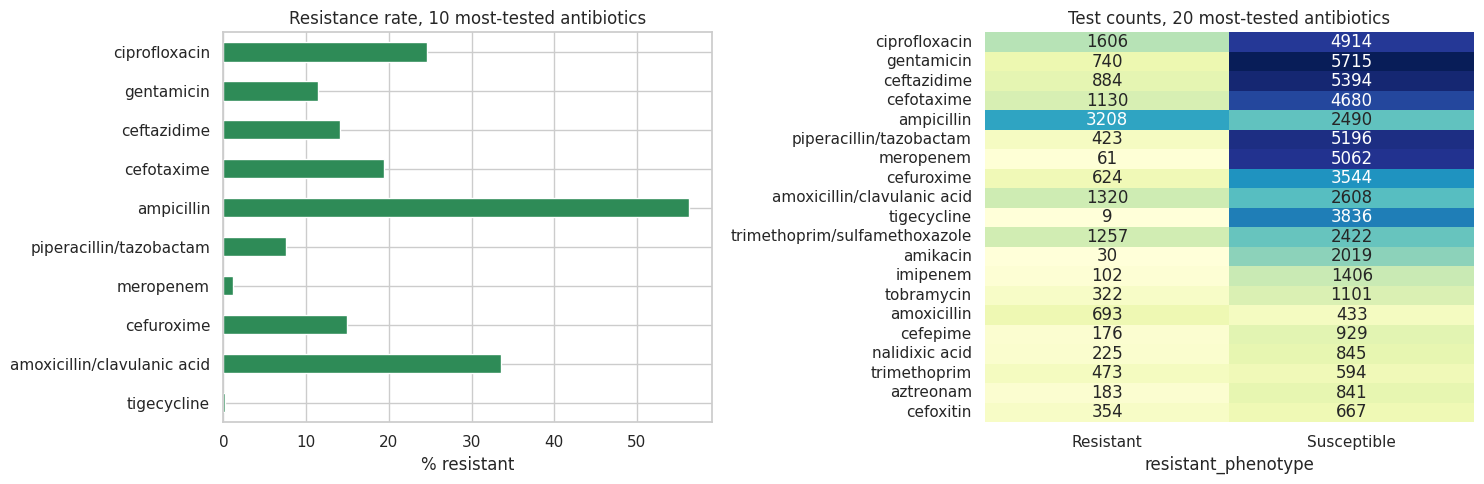

In [ ]:
abx_stats = (d.groupby("antibiotic")
               .agg(n_tests=("y", "size"), n_resistant=("y", "sum"))
               .assign(resistance_rate=lambda t: 100 * t.n_resistant / t.n_tests)
               .sort_values("n_tests", ascending=False))
TOP = abx_stats.head(10).index.tolist()
display(abx_stats.head(15).round(1))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
abx_stats.loc[TOP, "resistance_rate"].iloc[::-1].plot.barh(ax=axes[0], color="seagreen")
axes[0].set(title="Resistance rate, 10 most-tested antibiotics", xlabel="% resistant", ylabel="")
top20 = abx_stats.head(20).index
cnt = (d[d.antibiotic.isin(top20)].pivot_table(index="antibiotic", columns="resistant_phenotype",
                                                values="y", aggfunc="size", fill_value=0).loc[top20])
sns.heatmap(cnt, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1], cbar=False)
axes[1].set(title="Test counts, 20 most-tested antibiotics", ylabel="")
plt.tight_layout(); plt.show()

## Part 3. Replicate the paper's benchmark, then audit it

**Paper setup:** features derived only from the **antibiotic name** (LabelEncoder, then min-max scaling), target = R/S, stratified 80/20 split, 5-fold CV with grid search, five models.

Read the next cells with one question in mind: *if the only input is which antibiotic was tested, what is the model able to learn?*

In [ ]:
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold, GroupKFold,
                                     StratifiedGroupKFold)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             balanced_accuracy_score, matthews_corrcoef, RocCurveDisplay, roc_curve)
from xgboost import XGBClassifier

def model_zoo():
    return {
        "Random Forest": (RandomForestClassifier(random_state=SEED, n_jobs=-1),
                          {"n_estimators": [100, 300], "max_depth": [None, 10]}),
        "XGBoost": (XGBClassifier(eval_metric="logloss", random_state=SEED, n_jobs=-1),
                    {"n_estimators": [100, 300], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}),
        "SVM": (SVC(), {"C": [1, 10]}),
        "Logistic Regression": (LogisticRegression(max_iter=2000), {"C": [0.1, 1, 10]}),
        "kNN": (KNeighborsClassifier(), {"n_neighbors": [5, 15, 31]}),
    }

def get_score(model, X):
    return model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X)

def score_binary(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "precision_R": precision_score(y_true, y_pred, zero_division=0),
        "recall_R": recall_score(y_true, y_pred, zero_division=0),
        "f1_R": f1_score(y_true, y_pred, zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
    }

def run_models(X, y, skip=(), test_size=0.2):
    """Stratified 80/20 split; 5-fold grid search on the training part; metrics on the held-out 20%."""
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, stratify=y, random_state=SEED)
    cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
    rows, fitted = [], {}
    for name, (est, grid) in model_zoo().items():
        if name in skip:
            continue
        gs = GridSearchCV(est, grid, cv=cv, scoring="roc_auc", n_jobs=-1).fit(Xtr, ytr)
        m = gs.best_estimator_
        rows.append({"model": name, "cv_auc": gs.best_score_, **score_binary(yte, m.predict(Xte), get_score(m, Xte))})
        fitted[name] = m
    return pd.DataFrame(rows).set_index("model"), fitted, (Xte, yte)

,cv_auc,accuracy,balanced_acc,precision_R,recall_R,f1_R,f1_macro,mcc,roc_auc
model,,,,,,,,,
Random Forest,0.788,0.798,0.643,0.602,0.355,0.447,0.662,0.351,0.788
XGBoost,0.788,0.798,0.643,0.601,0.355,0.446,0.662,0.350,0.788
SVM,0.529,0.771,0.500,0.000,0.000,0.000,0.435,0.000,0.518
Logistic Regression,0.589,0.771,0.500,0.000,0.000,0.000,0.435,0.000,0.595
kNN,0.768,0.799,0.655,0.593,0.390,0.470,0.673,0.364,0.756


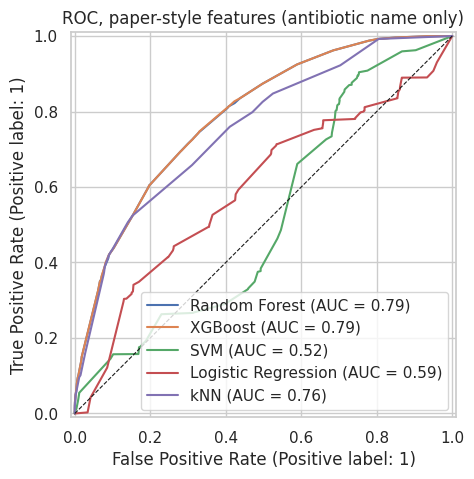

In [ ]:
# Paper-style features: LabelEncoder on the antibiotic name, then min-max scaling
y = d["y"].values
X_paper = MinMaxScaler().fit_transform(LabelEncoder().fit_transform(d["antibiotic"]).reshape(-1, 1))
res_paper, fitted_paper, (Xte_p, yte_p) = run_models(X_paper, y)
display(res_paper.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
for name, m in fitted_paper.items():
    RocCurveDisplay.from_estimator(m, Xte_p, yte_p, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", lw=0.8); ax.set_title("ROC, paper-style features (antibiotic name only)")
plt.show()

### 3.2 What are these numbers actually worth?

Two baselines that use **no machine learning at all**:
- *Majority class*: always predict "resistant".
- *Per-antibiotic prior*: for each antibiotic, predict the resistance rate seen in the training set. This is the information the paper's single feature can carry, nothing more.

We also test **one-hot** encoding. `LabelEncoder` + min-max imposes a fake numeric ordering on antibiotics (ampicillin < azithromycin < ...), which distorts SVM, logistic regression and kNN. Trees can cope with it; the other models cannot.

In [ ]:
idx = np.arange(len(d))
tr_i, te_i = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)  # same split as run_models
dtr, dte = d.iloc[tr_i], d.iloc[te_i]

maj = np.ones(len(dte), dtype=int)
base_major = score_binary(dte.y.values, maj, maj.astype(float) + rng.normal(0, 1e-9, len(maj)))
rate = dtr.groupby("antibiotic")["y"].mean()
p_prior = dte["antibiotic"].map(rate).fillna(dtr.y.mean()).values
base_prior = score_binary(dte.y.values, (p_prior >= 0.5).astype(int), p_prior)

X_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit_transform(d[["antibiotic"]])
res_ohe, _, _ = run_models(X_ohe, y, skip=("SVM",))   # SVM skipped: slow on 16k rows, no extra insight

table = pd.concat([
    res_paper.assign(features="paper (label-encoded)"),
    res_ohe.assign(features="one-hot"),
    pd.DataFrame({"majority class": base_major, "per-antibiotic prior (no ML)": base_prior}).T.assign(features="none"),
])
display(table.round(3))

,cv_auc,accuracy,balanced_acc,precision_R,recall_R,f1_R,f1_macro,mcc,roc_auc,features
Random Forest,0.788,0.798,0.643,0.602,0.355,0.447,0.662,0.351,0.788,paper (label-encoded)
XGBoost,0.788,0.798,0.643,0.601,0.355,0.446,0.662,0.350,0.788,paper (label-encoded)
SVM,0.529,0.771,0.500,0.000,0.000,0.000,0.435,0.000,0.518,paper (label-encoded)
Logistic Regression,0.589,0.771,0.500,0.000,0.000,0.000,0.435,0.000,0.595,paper (label-encoded)
kNN,0.768,0.799,0.655,0.593,0.390,0.470,0.673,0.364,0.756,paper (label-encoded)
Random Forest,0.788,0.799,0.644,0.603,0.357,0.449,0.663,0.352,0.788,one-hot
XGBoost,0.788,0.798,0.642,0.601,0.354,0.446,0.661,0.350,0.788,one-hot
Logistic Regression,0.788,0.799,0.643,0.602,0.356,0.448,0.662,0.352,0.788,one-hot
kNN,0.769,0.799,0.655,0.593,0.388,0.469,0.673,0.364,0.757,one-hot
majority class,NaN,0.229,0.500,0.229,1.000,0.373,0.186,0.000,0.496,none


**How to read this table.** If the per-antibiotic prior lands close to XGBoost's ROC-AUC, then XGBoost has learned "ampicillin is almost always resistant, meropenem rarely", which is useful surveillance information but is **not** predicting whether *this isolate* is resistant. The F1 for the resistant class (~0.56 in the paper) is the more honest signal.

Isolate-level prediction requires **isolate-level features**, which is Part 4.

## Part 4. Genome-derived features

### 4.1 Pick genomes and download FASTA files
We sample genomes that were tested against at least 3 of the top antibiotics. Start with a few hundred; the pipeline scales linearly, so raise `N_GENOMES` when everything works. A random sample is used here; for a paper, sample deliberately (e.g. by geography or year) and report it.

In [ ]:
cand = d[d["antibiotic"].isin(TOP)]
n_tested = cand.groupby("genome_id")["antibiotic"].nunique()
eligible = n_tested[n_tested >= 3].index.to_numpy()
chosen = sorted(rng.choice(eligible, size=min(N_GENOMES, len(eligible)), replace=False).tolist())
print(f"{len(eligible)} eligible genomes, using {len(chosen)}")

def _dl(gid):
    try:
        return gid, download_genome_fasta(gid)
    except Exception as e:
        return gid, None

with ThreadPoolExecutor(N_THREADS) as ex:
    results = list(tqdm(ex.map(_dl, chosen), total=len(chosen), desc="genomes"))
fasta = {g: p for g, p in results if p is not None}
print(f"Downloaded {len(fasta)}/{len(chosen)} genomes")

### 4.2 Annotate resistance determinants with AMRFinderPlus
One tool gives us **acquired genes and point mutations** (e.g. `gyrA_S83L`, `parC_S80I`) in a single tidy table, which makes it a practical feature builder. The paper's tools (CARD RGI, ResFinder) are run as a cross-check in 4.3.

In [ ]:
def run_amrfinder(gid):
    out = ANNOT / f"{gid}.amrfinder.tsv"
    if out.exists() and out.stat().st_size > 0:
        return gid, out
    cmd = ["amrfinder", "-n", str(fasta[gid]), "--organism", "Escherichia", "--plus",
           "--threads", "1", "-o", str(out)]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(gid, "amrfinder failed:", r.stderr[-200:])
        return gid, None
    return gid, out

todo = [g for g in fasta if not (ANNOT / f"{g}.amrfinder.tsv").exists()]
if todo and not shutil.which("amrfinder"):
    raise RuntimeError("amrfinder not found. See Part 0 for installation (and run `amrfinder -u` once).")
with ThreadPoolExecutor(N_THREADS) as ex:
    done = list(tqdm(ex.map(run_amrfinder, list(fasta)), total=len(fasta), desc="AMRFinderPlus"))
annotated = {g: p for g, p in done if p is not None}
print(f"Annotated {len(annotated)} genomes")

In [ ]:
def parse_amrfinder(path):
    t = pd.read_csv(path, sep="\t")
    sym = "Element symbol" if "Element symbol" in t.columns else "Gene symbol"
    typ = "Type" if "Type" in t.columns else "Element type"
    out = t[[sym, typ, "Class", "Subclass"]].copy()
    out.columns = ["symbol", "type", "class", "subclass"]
    return out

def clean_name(s):  # XGBoost forbids [ ] < > in feature names
    return re.sub(r"[\[\]<>]", "_", s)

presence, meta = {}, []
for gid, path in annotated.items():
    hits = parse_amrfinder(path)
    hits = hits[hits["type"].isin(["AMR", "POINT", "STRESS"]) | hits["type"].isna()]
    presence[gid] = set(hits["symbol"].map(clean_name))
    meta.append(hits.assign(symbol=hits["symbol"].map(clean_name)))

all_feats = sorted(set().union(*presence.values()))
G_full = pd.DataFrame([[int(f in presence[g]) for f in all_feats] for g in annotated], index=list(annotated),
                      columns=all_feats)
feat_meta = pd.concat(meta).drop_duplicates("symbol").set_index("symbol")

# keep features present in at least 5 genomes and absent from at least 5 (uninformative otherwise)
keep = (G_full.sum() >= 5) & (G_full.sum() <= len(G_full) - 5)
G = G_full.loc[:, keep]
print(f"{G_full.shape[1]} distinct determinants found, {G.shape[1]} kept for modelling, {G.shape[0]} genomes")
display(G_full.sum().sort_values(ascending=False).head(15).to_frame("n_genomes").join(feat_meta[["type", "class"]]))

### 4.3 (Optional) Cross-check with the paper's tools: CARD RGI and ResFinder
Set `RUN_PAPER_TOOLS = True` in the config cell. One-off database setup:

```bash
# CARD / RGI
wget https://card.mcmaster.ca/latest/data -O card_data.tar.bz2 && mkdir -p card && tar -xjf card_data.tar.bz2 -C card
rgi load --card_json card/card.json --local

# ResFinder + PointFinder databases (check the ResFinder README for the current hosting location)
git clone https://bitbucket.org/genomicepidemiology/resfinder_db/   && git clone https://bitbucket.org/genomicepidemiology/pointfinder_db/
```
Command-line flags change between versions; confirm with `rgi main --help` and `run_resfinder.py --help` if a call fails.

In [ ]:
if RUN_PAPER_TOOLS:
    sub = list(fasta)[:N_CROSSCHECK]
    for gid in tqdm(sub, desc="RGI + ResFinder"):
        subprocess.run(["rgi", "main", "-i", str(fasta[gid]), "-o", str(ANNOT / f"{gid}.rgi"), "-t", "contig",
                        "-a", "BLAST", "-n", str(N_THREADS), "--include_loose", "--local", "--clean"])
        subprocess.run(["run_resfinder.py", "-ifa", str(fasta[gid]), "-o", str(ANNOT / f"{gid}_resfinder"),
                        "-s", "Escherichia coli", "--acquired", "--point"])
    rgi_tbl = pd.concat([pd.read_csv(ANNOT / f"{g}.rgi.txt", sep="\t").assign(genome_id=g)
                         for g in sub if (ANNOT / f"{g}.rgi.txt").exists()], ignore_index=True)
    cols = [c for c in ["Best_Hit_ARO", "Drug Class", "Resistance Mechanism", "Cut_Off", "SNPs_in_Best_Hit_ARO"]
            if c in rgi_tbl.columns]
    display(rgi_tbl.groupby(cols).size().rename("n_genomes").reset_index().sort_values("n_genomes", ascending=False).head(25))
    for g in sub[:3]:
        for f in (ANNOT / f"{g}_resfinder").glob("*results*.txt"):
            print(f); display(pd.read_csv(f, sep="\t").head())
else:
    print("Skipped (RUN_PAPER_TOOLS = False).")

## Part 5. Phylogeny, with an actual statistical test

The paper's tree was descriptive: no support values and no clustering statistic. Also, MAFFT on whole bacterial genomes is not a standard approach (rearrangements, memory), and Fig. 7B in the paper appears to show *gene features of one genome* rather than isolates.

Here we use **mashtree** (fast, k-mer distance based, designed for hundreds to thousands of genomes), then test whether resistant isolates are phylogenetically clustered with a **permutation test** on patristic (tree) distances.

In [ ]:
TREE_NWK = DATA / "mashtree.dnd"
tree_inputs = [fasta[g] for g in fasta]
if K12 is not None:
    shutil.copy(K12, GENOMES / "K12_MG1655.fna"); tree_inputs.append(GENOMES / "K12_MG1655.fna")

if not TREE_NWK.exists():
    if not shutil.which("mashtree"):
        raise RuntimeError("mashtree not found. See Part 0.")
    subprocess.run(["mashtree", "--numcpus", str(N_THREADS), "--outtree", str(TREE_NWK)] + [str(p) for p in tree_inputs],
                   check=True)
print("Tree file:", TREE_NWK, TREE_NWK.stat().st_size, "bytes")

In [ ]:
from Bio import Phylo
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

def load_tree(path):
    t = Phylo.read(str(path), "newick")
    for tip in t.get_terminals():
        tip.name = re.sub(r"\.(fna|fasta|fa)$", "", tip.name or "")
    return t

def patristic_matrix(tree):
    """Pairwise tree distances (sum of branch lengths on the path between two tips)."""
    depth = {id(tree.root): 0.0}
    for clade in tree.find_clades(order="level"):
        for ch in clade.clades:
            depth[id(ch)] = depth[id(clade)] + (ch.branch_length or 0.0)
    tips = tree.get_terminals()
    paths = [[id(c) for c in tree.get_path(t)] for t in tips]
    n = len(tips); D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            a, b = paths[i], paths[j]
            k, m = 0, min(len(a), len(b))
            while k < m and a[k] == b[k]:
                k += 1
            lca = depth[a[k - 1]] if k > 0 else 0.0
            D[i, j] = D[j, i] = depth[a[-1]] + depth[b[-1]] - 2 * lca
    return [t.name for t in tips], D

def clustering_test(D, is_case, n_perm=2000):
    """Are 'case' tips closer to each other than expected by chance? One-sided permutation test."""
    is_case = np.asarray(is_case, dtype=bool)
    iu = lambda k: np.triu_indices(k, 1)
    def stat(lbl):
        ix = np.where(lbl)[0]
        return D[np.ix_(ix, ix)][iu(len(ix))].mean()
    obs = stat(is_case)
    null = np.array([stat(rng.permutation(is_case)) for _ in range(n_perm)])
    return obs, null.mean(), (np.sum(null <= obs) + 1) / (n_perm + 1)

def plot_tree(tree, color_of, title, figsize=(9, None)):
    n = len(tree.get_terminals())
    fig, ax = plt.subplots(figsize=(figsize[0], figsize[1] or max(6, 0.11 * n)))
    with plt.rc_context({"font.size": 5}):
        Phylo.draw(tree, axes=ax, do_show=False, show_confidence=False,
                   label_func=lambda c: c.name if c.is_terminal() else None,
                   label_colors=lambda name: color_of.get(name, "grey"))
    ax.set_title(title); plt.show()

tree = load_tree(TREE_NWK)
tip_names, D = patristic_matrix(tree)
tip_ix = {n: i for i, n in enumerate(tip_names)}
print(len(tip_names), "tips; max patristic distance", D.max().round(4))

# lineage groups for leakage-aware cross-validation
gen_tips = [n for n in tip_names if n in G.index]
sel = [tip_ix[n] for n in gen_tips]
Z = linkage(squareform(D[np.ix_(sel, sel)], checks=False), "average")
cluster_of = dict(zip(gen_tips, fcluster(Z, t=CLUSTERS_FOR_CV, criterion="maxclust")))
print("Lineage-group sizes:", sorted(pd.Series(cluster_of).value_counts().tolist(), reverse=True))

In [ ]:
lab = d[d["genome_id"].isin(G.index)][["genome_id", "antibiotic", "y"]]
rows = []
for abx in TOP:
    s = lab[lab.antibiotic == abx]
    s = s[s.genome_id.isin(tip_ix)]
    if len(s) < 30 or s.y.sum() < 8 or (len(s) - s.y.sum()) < 8:
        continue
    ix = np.array([tip_ix[g] for g in s.genome_id])
    obs_r, null_r, p_r = clustering_test(D[np.ix_(ix, ix)], s.y.values == 1)
    obs_s, null_s, p_s = clustering_test(D[np.ix_(ix, ix)], s.y.values == 0)
    rows.append({"antibiotic": abx, "n_R": int(s.y.sum()), "n_S": int((1 - s.y).sum()),
                 "mean_dist_R": obs_r, "null_R": null_r, "p_R_clustered": p_r,
                 "mean_dist_S": obs_s, "p_S_clustered": p_s})
phylo_stats = pd.DataFrame(rows)
display(phylo_stats.round(4))

# colour tips by ciprofloxacin (or the first quinolone available) phenotype
fq = next((a for a in TOP if "floxacin" in a), TOP[0])
pheno = lab[lab.antibiotic == fq].set_index("genome_id")["y"]
color_of = {g: ("crimson" if v == 1 else "steelblue") for g, v in pheno.items()}
color_of["K12_MG1655"] = "black"
plot_tree(tree, color_of, f"Mash tree, tips coloured by {fq}: red = resistant, blue = susceptible, black = K-12")

**Reading `phylo_stats`:** a small `p_R_clustered` means resistant isolates sit closer together on the tree than random label shuffling predicts, which is evidence of clonal spread (for example ST131-like lineages). It also warns that ordinary random cross-validation will be **optimistic**, because near-identical genomes land in both train and test. Part 6 handles this directly.

### 5.3 (Optional) The paper's own approach: whole-genome MAFFT + FastTree (GTR)
Only for a **small** subset, and only to see how it behaves. Contigs of each genome are concatenated into one sequence, which is what a naive whole-genome alignment amounts to. Add Cronobacter/Atlantibacter BV-BRC genome IDs to `OUTGROUP_IDS` to root the tree as in the paper.

In [ ]:
if RUN_PAPER_STYLE_TREE:
    from Bio import SeqIO
    ft = next((shutil.which(n) for n in ("FastTree", "fasttree") if shutil.which(n)), None)
    assert shutil.which("mafft") and ft, "mafft/FastTree not found"
    members = {g: fasta[g] for g in list(fasta)[:N_TREE_WGA]}
    if K12 is not None:
        members["K12_MG1655"] = K12
    for og in OUTGROUP_IDS:
        members[f"OUT_{og}"] = download_genome_fasta(og)
    inp, aln, nwk = DATA / "wga_in.fasta", DATA / "wga_aln.fasta", DATA / "wga_fasttree.nwk"
    with open(inp, "w") as f:
        for name, path in members.items():
            f.write(f">{name}\n" + "".join(str(r.seq) for r in SeqIO.parse(path, "fasta")) + "\n")
    with open(aln, "w") as f:
        subprocess.run(["mafft", "--auto", "--thread", str(N_THREADS), str(inp)], stdout=f, check=True)
    with open(nwk, "w") as f:
        subprocess.run([ft, "-nt", "-gtr", "-gamma", str(aln)], stdout=f, check=True)
    t2 = Phylo.read(str(nwk), "newick")
    if OUTGROUP_IDS:
        t2.root_with_outgroup([c for c in t2.get_terminals() if c.name.startswith("OUT_")][0])
    plot_tree(t2, color_of, "Paper-style tree (MAFFT + FastTree, GTR). Support values are FastTree local supports.")
else:
    print("Skipped (RUN_PAPER_STYLE_TREE = False).")

## Part 6. Predict resistance from the genome

### 6.1 One model per antibiotic, two validation schemes
- **Random stratified 5-fold CV** (what most papers do).
- **Lineage-aware 5-fold CV**: whole phylogenetic groups are held out together (`StratifiedGroupKFold`), so the model must generalise to genomes unlike those it trained on.

Plus a **rule-based baseline**: "predict resistant if the genome carries any determinant for that drug class." If XGBoost cannot beat this, the ML adds little.

In [ ]:
def cv_oof(X, y, groups=None, n_splits=5):
    """Out-of-fold predicted probabilities from XGBoost."""
    if groups is None:
        splits = StratifiedKFold(n_splits, shuffle=True, random_state=SEED).split(X, y)
    else:
        splits = StratifiedGroupKFold(n_splits, shuffle=True, random_state=SEED).split(X, y, groups)
    oof = np.full(len(y), np.nan)
    for tr, te in splits:
        m = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.8,
                          colsample_bytree=0.8, eval_metric="logloss", random_state=SEED, n_jobs=-1)
        m.fit(X.iloc[tr], y[tr]); oof[te] = m.predict_proba(X.iloc[te])[:, 1]
    return oof

def metrics_from_oof(y, p):
    return {"auc": roc_auc_score(y, p), "mcc": matthews_corrcoef(y, (p >= 0.5).astype(int)),
            "bal_acc": balanced_accuracy_score(y, (p >= 0.5).astype(int))}

CLASS_RULES = [("floxacin", ["QUINOLONE"]), ("nalidixic", ["QUINOLONE"]), ("penem", ["BETA-LACTAM"]),
               ("cillin", ["BETA-LACTAM"]), ("cef", ["BETA-LACTAM"]), ("ceph", ["BETA-LACTAM"]),
               ("aztreonam", ["BETA-LACTAM"]), ("gentamicin", ["AMINOGLYCOSIDE"]), ("amikacin", ["AMINOGLYCOSIDE"]),
               ("tobramycin", ["AMINOGLYCOSIDE"]), ("streptomycin", ["AMINOGLYCOSIDE"]),
               ("tetracycline", ["TETRACYCLINE"]), ("doxycycline", ["TETRACYCLINE"]),
               ("trimethoprim", ["TRIMETHOPRIM", "SULFONAMIDE"]), ("sulf", ["SULFONAMIDE"])]

def rule_baseline(abx, X):
    tokens = next((t for k, t in CLASS_RULES if k in abx), None)
    if tokens is None:
        return None
    cls = feat_meta.reindex(X.columns)["class"].fillna("")
    cols = [c for c in X.columns if any(t in cls[c] for t in tokens)]
    return X[cols].sum(axis=1).values if cols else np.zeros(len(X))

rows, oof_cache = [], {}
for abx in TOP:
    s = lab[(lab.antibiotic == abx) & lab.genome_id.isin(cluster_of)]
    if len(s) < 60 or s.y.sum() < 10 or (len(s) - s.y.sum()) < 10:
        continue
    X = G.loc[s.genome_id]; yv = s.y.values; grp = s.genome_id.map(cluster_of).values
    p_rand, p_lin = cv_oof(X, yv), cv_oof(X, yv, groups=grp)
    oof_cache[abx] = (s.genome_id.values, yv, p_lin)
    rule = rule_baseline(abx, X)
    row = {"antibiotic": abx, "n": len(s), "prevalence_R": yv.mean(),
           **{f"{k}_randomCV": v for k, v in metrics_from_oof(yv, p_rand).items()},
           **{f"{k}_lineageCV": v for k, v in metrics_from_oof(yv, p_lin).items()}}
    if rule is not None:
        row["auc_rule"] = roc_auc_score(yv, rule); row["mcc_rule"] = matthews_corrcoef(yv, (rule > 0).astype(int))
    rows.append(row)
per_abx = pd.DataFrame(rows).set_index("antibiotic")
display(per_abx.round(3))

### 6.2 Which features drive predictions? SHAP plus an association test
SHAP shows what the model uses; a Fisher exact test with FDR correction shows which determinants associate with the phenotype on their own. Agreement between the two, and with known biology (*gyrA* S83L/D87N, *parC* S80I, *bla*CTX-M-15, *aac(3)-IIa*, *tet(A)*), is the real "biological validation", not simply listing genes found in the genomes.

In [ ]:
import shap
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

target = fq if fq in oof_cache else next(iter(oof_cache))
ids, yv, _ = oof_cache[target]
X = G.loc[ids]
m = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                  eval_metric="logloss", random_state=SEED, n_jobs=-1).fit(X, yv)
sv = shap.TreeExplainer(m).shap_values(X)
imp = pd.Series(np.abs(sv).mean(0), index=X.columns).sort_values(ascending=False)

fisher = []
for f in X.columns:
    a = int(((X[f] == 1) & (yv == 1)).sum()); b = int(((X[f] == 1) & (yv == 0)).sum())
    c = int(((X[f] == 0) & (yv == 1)).sum()); e = int(((X[f] == 0) & (yv == 0)).sum())
    odds, p = fisher_exact([[a, b], [c, e]])
    fisher.append({"feature": f, "R_with": a, "S_with": b, "odds_ratio": (a + .5) * (e + .5) / ((b + .5) * (c + .5)), "p": p})
fisher = pd.DataFrame(fisher).set_index("feature")
fisher["q_fdr"] = multipletests(fisher["p"], method="fdr_bh")[1]
summary = fisher.join(imp.rename("mean_abs_SHAP")).join(feat_meta[["class"]]).sort_values("mean_abs_SHAP", ascending=False)
print(f"Target antibiotic: {target}")
display(summary.head(15).round(4))

fig, ax = plt.subplots(figsize=(6, 5))
imp.head(15).iloc[::-1].plot.barh(ax=ax, color="darkorange")
ax.set(title=f"Top determinants for {target} (mean |SHAP|)"); plt.tight_layout(); plt.show()

### 6.3 One joint model across antibiotics: do genes add to the paper's features?
This is the fair head-to-head with the paper's design (one model, many antibiotics), evaluated with lineage-aware folds and grouped by genome so the same isolate never appears in both train and test.

| Variant | Inputs |
|---|---|
| antibiotic only | one-hot antibiotic (the paper's information) |
| genes only | AMR determinants |
| genes + antibiotic | both, letting trees learn gene x drug interactions |

**Expect "genes only" to look weak here.** That model sees a genome's determinants but is never told *which drug* the row refers to, so it cannot know whether `gyrA_S83L` matters (it does for ciprofloxacin, not for gentamicin). Genes alone only help once the drug is also known, which is why the combined variant is the meaningful comparison against the paper's "antibiotic only" design.

In [ ]:
pairs = lab[lab.genome_id.isin(cluster_of) & lab.antibiotic.isin(TOP)].reset_index(drop=True)
Xg = G.loc[pairs.genome_id].reset_index(drop=True)
Xa = pd.get_dummies(pairs["antibiotic"], prefix="abx").astype(int)
yp = pairs["y"].values; grp = pairs["genome_id"].map(cluster_of).values

variants = {"antibiotic only": Xa, "genes only": Xg, "genes + antibiotic": pd.concat([Xg, Xa], axis=1)}
joint_rows, joint_oof = [], {}
for name, X in variants.items():
    p = cv_oof(X, yp, groups=grp); joint_oof[name] = p
    joint_rows.append({"variant": name, "n_pairs": len(yp), **metrics_from_oof(yp, p)})
joint = pd.DataFrame(joint_rows).set_index("variant")
display(joint.round(3))

### 6.4 The clinical trade-off the paper only mentions
A false negative (resistant predicted susceptible) means ineffective therapy; a false positive pushes clinicians toward broader or last-resort drugs. Instead of the default 0.5 cut-off, pick the threshold that guarantees a target sensitivity for resistance and see what specificity you pay.

In [ ]:
p = joint_oof["genes + antibiotic"]
fpr, tpr, thr = roc_curve(yp, p)
rows = []
for target_sens in (0.90, 0.95, 0.99):
    i = np.argmax(tpr >= target_sens)
    rows.append({"target_sensitivity": target_sens, "threshold": thr[i], "sensitivity": tpr[i], "specificity": 1 - fpr[i]})
display(pd.DataFrame(rows).round(3))

## Part 7. Save outputs and a reproducibility log

In [ ]:
outputs = {"cleaning_flow": pd.DataFrame(flow), "antibiotic_stats": abx_stats, "paper_replication": table,
           "phylo_clustering": phylo_stats, "per_antibiotic_models": per_abx, "determinant_summary": summary,
           "joint_models": joint, "genome_feature_matrix": G}
for name, frame in outputs.items():
    frame.to_csv(RES / f"{name}.csv")
print("Saved:", sorted(p.name for p in RES.glob("*.csv")))

import sklearn, xgboost, scipy, Bio
versions = {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
            "scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__, "shap": shap.__version__,
            "scipy": scipy.__version__, "biopython": Bio.__version__, "seed": SEED}
for tool, flag in {"amrfinder": "--version", "mashtree": "--version", "mafft": "--version"}.items():
    if shutil.which(tool):
        r = subprocess.run([tool, flag], capture_output=True, text=True)
        versions[tool] = (r.stdout or r.stderr).strip().splitlines()[0] if (r.stdout or r.stderr).strip() else "?"
versions["BV-BRC download date"] = time.strftime("%Y-%m-%d", time.gmtime(RAW.stat().st_mtime)) if RAW.exists() else "?"
(RES / "run_versions.json").write_text(json.dumps(versions, indent=2, default=str))
print(json.dumps(versions, indent=2, default=str))

## Part 8. Paper limitations and how this notebook addresses them

| Issue in the paper | What was done here |
|---|---|
| Only feature is the antibiotic name, so ML mostly learns per-drug base rates | Baselines in 3.2 quantify this; genome-derived features in Parts 4-6 |
| `LabelEncoder` + min-max on a nominal variable (fake ordering hurts SVM/LR/kNN) | One-hot comparison in 3.2 |
| Random CV with repeated genomes and clonal lineages leaks information | Group by genome, plus lineage-aware `StratifiedGroupKFold` (6.1, 6.3) |
| No baseline beyond other ML models | Majority, per-drug prior, and rule-based baselines |
| Accuracy and ROC-AUC headline; precision/recall about 0.55 | MCC, balanced accuracy, per-class F1 and sensitivity-targeted thresholds (6.4) |
| Intermediate isolates silently dropped; the text later mentions intermediate samples | Counted and reported in the cleaning flow table |
| Computational phenotypes could contaminate labels | Laboratory evidence filter |
| Genomic analysis was a post-hoc literature check, not an input or a test | Determinants are model inputs; SHAP plus FDR-corrected Fisher tests (6.2) |
| Whole-genome MAFFT tree, no support values, no clustering statistic | Mash tree plus permutation test (Part 5); paper-style tree kept as an option |
| Genes named in the conclusion (e.g. *qnrS*) not shown in the results | Every reported determinant comes from a saved annotation table |

**Natural next steps:** add MLST sequence types as grouping variable; external validation on a different database or later submission period; calibration curves; cost-sensitive decision thresholds; extend from a hand-picked top-10 to MIC regression; expand to other ESKAPE pathogens; explore k-mer or pan-genome features (e.g. Panaroo + Scoary) beyond curated AMR determinants.